# pinball_endpoint

In [1]:
# Import the experiment config, the results loader and the analysis functions.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from analysis.curves import return_curve, subsample
from analysis.stats import mean_ci
from main import load_results

from config import EXPERIMENT

PLOTS_DIR = EXPERIMENT.results_dir.parent / "plots"

In [2]:
# Each figure's panels, left to right, and each panel's agents in drawing order
# with their colors. Endpoint comes last so it is drawn on top.
FIGURES = {
    "curves": {
        "proportional": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Segment Recent": ("segmented", "tab:green"),
            "Segment Old": ("backward_segmented", "tab:blue"),
            "Subsample History": ("segmented_subsample", "#a90064"),
            "Endpoint History": ("segmented_endpoint", "tab:purple"),
            "Connected History": ("segmented_connected", "tab:brown"),
        },
        "weighted": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Weighted Segment Recent": ("segmented_weighted", "tab:green"),
            "Weighted Segment Old": ("backward_segmented_weighted", "tab:blue"),
            "Weighted Subsample History": ("segmented_weighted_subsample", "#a90064"),
            "Weighted Endpoint History": ("segmented_weighted_endpoint", "tab:purple"),
            "Weighted Connected History": ("segmented_weighted_connected", "tab:brown"),
        },
        "highly_weighted": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Highly Weighted Segment Recent": ("segmented_highly_weighted", "tab:green"),
            "Highly Weighted Segment Old": ("backward_segmented_highly_weighted", "tab:blue"),
            "Highly Subsample History": ("segmented_highly_weighted_subsample", "#a90064"),
            "Highly Endpoint History": ("segmented_highly_weighted_endpoint", "tab:purple"),
            "Highly Connected History": ("segmented_highly_weighted_connected", "tab:brown"),
        },
        "blocked": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Blocked Segment Recent": ("segmented_blocked", "tab:green"),
            "Blocked Segment Old": ("backward_segmented_blocked", "tab:blue"),
            "Blocked Subsample History": ("segmented_blocked_subsample", "#a90064"),
            "Blocked Endpoint History": ("segmented_blocked_endpoint", "tab:purple"),
            "Blocked Connected History": ("segmented_blocked_connected", "tab:brown"),
        },
    },
    "curves_tiny": {
        "proportional": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Segment Recent": ("segmented_tiny", "tab:green"),
            "Segment Old": ("backward_segmented_tiny", "tab:blue"),
            "Subsample History": ("segmented_subsample_tiny", "#a90064"),
            "Endpoint History": ("segmented_endpoint_tiny", "tab:purple"),
            "Connected History": ("segmented_connected_tiny", "tab:brown")
        },
        "weighted": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Weighted Segment Recent": ("segmented_weighted_tiny", "tab:green"),
            "Weighted Segment Old": ("backward_segmented_weighted_tiny", "tab:blue"),
            "Weighted Subsample History": ("segmented_weighted_subsample_tiny", "#a90064"),
            "Weighted Endpoint History": ("segmented_weighted_endpoint_tiny", "tab:purple"),
            "Weighted Connected History": ("segmented_weighted_connected_tiny", "tab:brown"),
        },
        "highly_weighted": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Highly Weighted Segment Recent": ("segmented_highly_weighted_tiny", "tab:green"),
            "Highly Weighted Segment Old": ("backward_segmented_highly_weighted_tiny", "tab:blue"),
            "Highly Subsample History": ("segmented_highly_weighted_subsample_tiny", "#a90064"),
            "Highly Endpoint History": ("segmented_highly_weighted_endpoint_tiny", "tab:purple"),
            "Highly Connected History": ("segmented_highly_weighted_connected_tiny", "tab:brown"),
        },
        "blocked": {
            "Unsegmented": ("ddqn_pinball", "black"),
            "Blocked Segment Recent": ("segmented_blocked_tiny", "tab:green"),
            "Blocked Segment Old": ("backward_segmented_blocked_tiny", "tab:blue"),
            "Blocked Subsample History": ("segmented_blocked_subsample_tiny", "#a90064"),
            "Blocked Endpoint History": ("segmented_blocked_endpoint_tiny", "tab:purple"),
            "Blocked Connected History": ("segmented_blocked_connected_tiny", "tab:brown"),
        },
    },
}

In [3]:
# Load each component's stored runs once and compute its mean return over seeds
# with a 95% bootstrap CI.
names = {
    name
    for panels in FIGURES.values()
    for agents in panels.values()
    for name, _ in agents.values()
}
curves = {}
for name in names:
    runs = load_results(EXPERIMENT, name)
    if runs is not None:
        timesteps, returns = subsample(return_curve(runs.reward, runs.done))
        curves[name] = (timesteps, mean_ci(returns), len(returns))

In [4]:
# Style for the learning-curve plots. Every piece of text shares one size.
FONT_SIZE = 32
STYLE = {
    "figure.figsize": (32, 8),
    "font.family": "Times New Roman",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "lines.linewidth": 2.5,
    "legend.frameon": False,
}
BAND_ALPHA = 0.2
# A figure's panels share colors, so only the left one carries the legend.
LEGEND = {
    "loc": "lower right",
    "bbox_to_anchor": (1.04, -0.04),
    "handlelength": 1,
    "handletextpad": 0.4,
}
LEGEND_MARKER = {"marker": "o", "linestyle": "none", "markersize": 14}
# The five-entry legend is too tall for one column at this font size.
LEGEND_LAYOUTS = {
    "paper_curves": {"ncol": 2, "columnspacing": 0.8, "fontsize": 28},
}
LEGEND_ORDER = [
    "Unsegmented",
    "Segment Recent",
    "Segment Old",
    "Subsample History",
    "Endpoint History",
    "Connected History",
]
# Memory relative to the 10k large-recency buffer.
TITLES = {
    "proportional": "Proportional sampling (10/90)",
    "weighted": "Weighted sampling (50/50)",
    "highly_weighted": "Weighted sampling (90/10)",
    "blocked": "Only segment (100/0)",
    }
BOX_ASPECT = 1
# Ticks sit only at the axis ends, so the labels can tuck in between them.
LABEL_PAD = -20
XLABEL = "Time Steps"
XTICKS = [0, 100_000]
XTICK_LABELS = ["0", "100k"]
YLABEL = "Return"
YTICKS = [-1000, 0]
YTICK_LABELS = ["-1k", "0"]

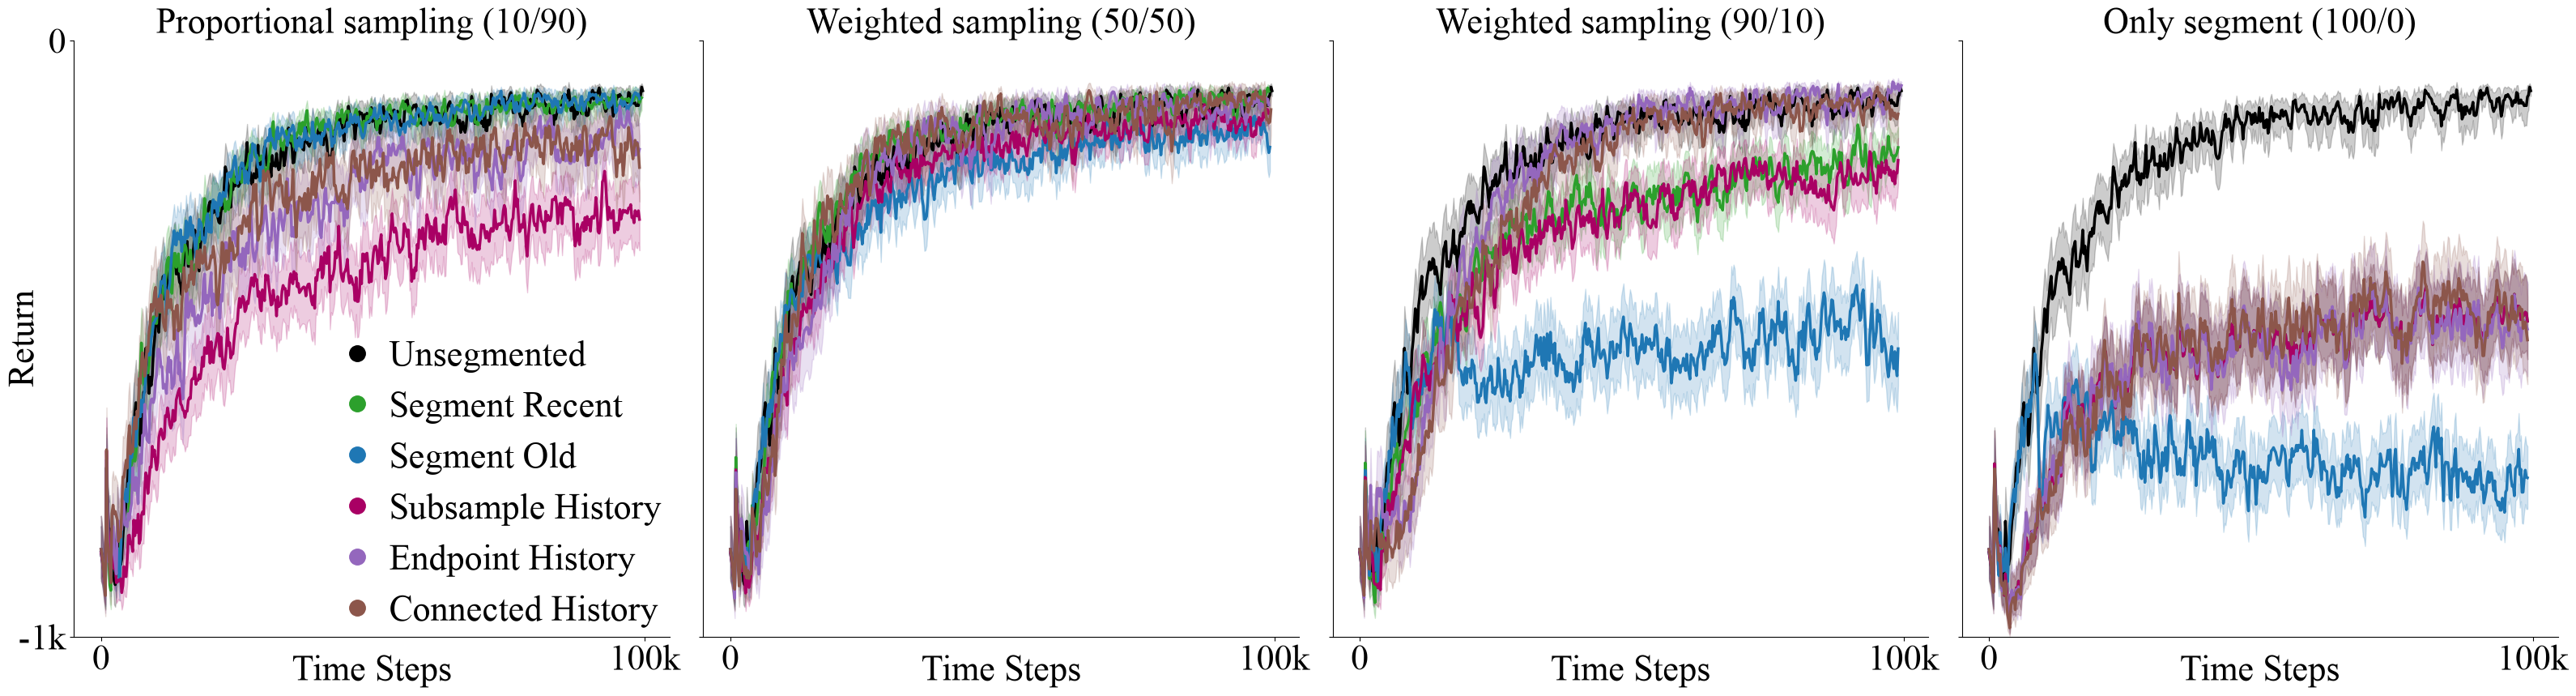

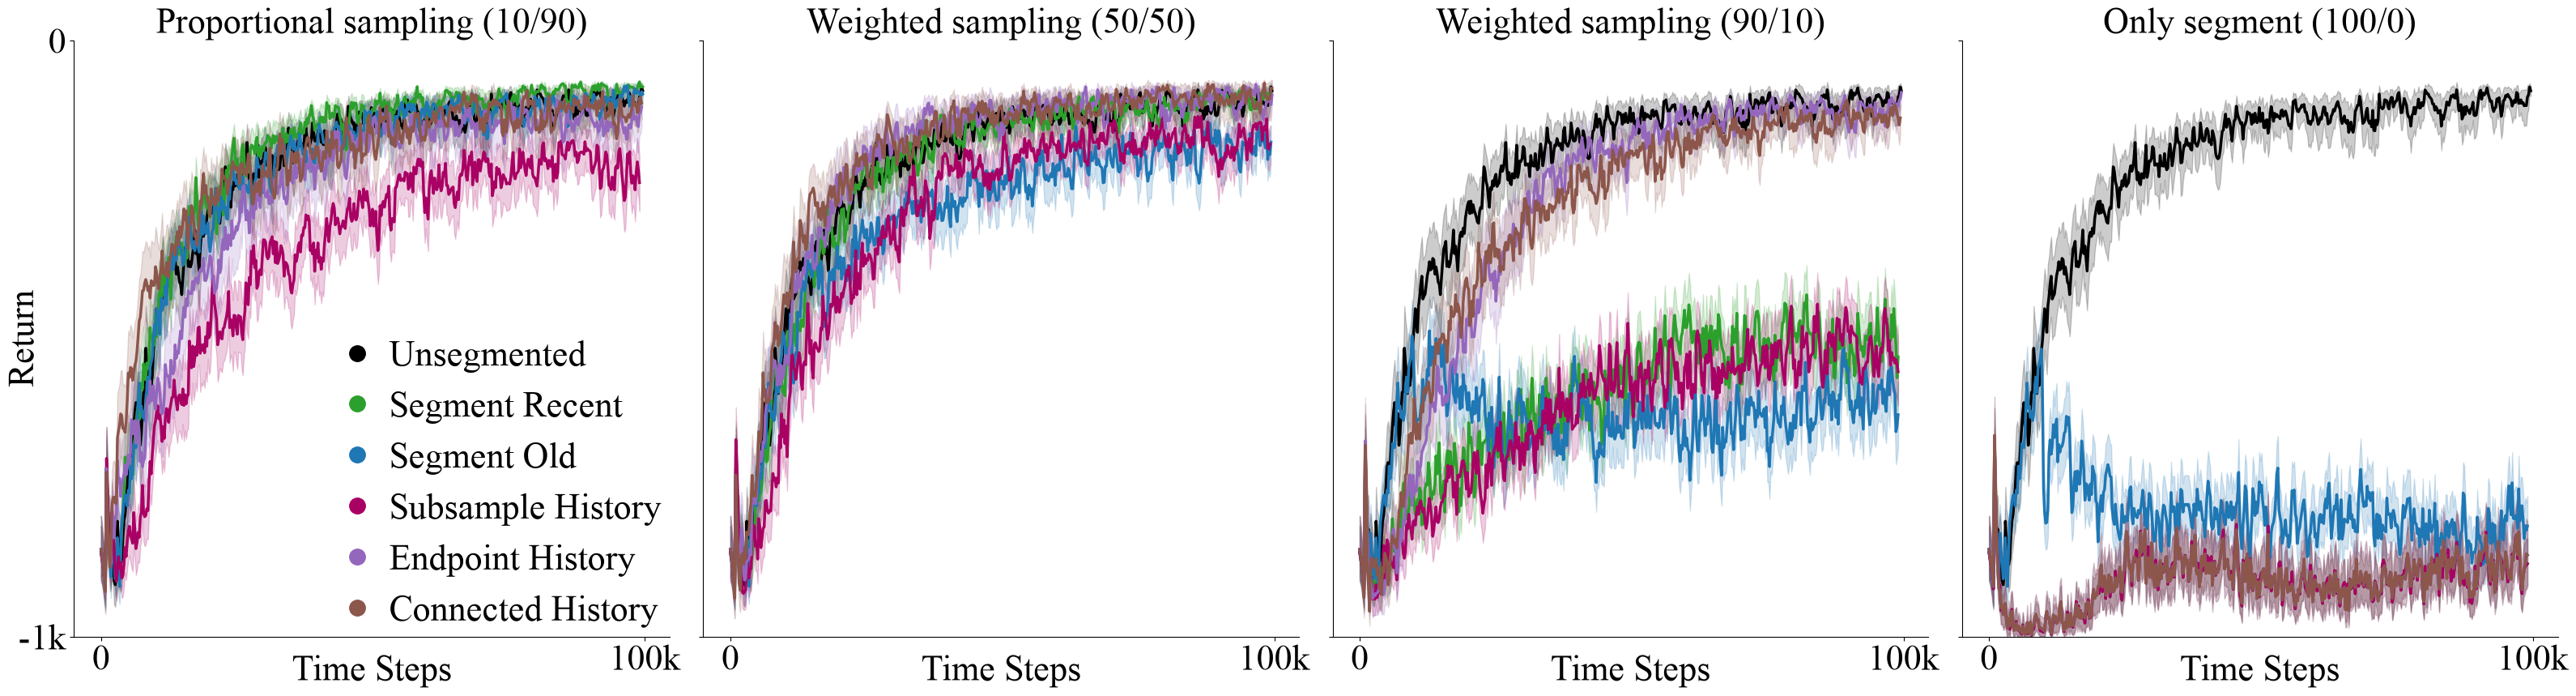

In [5]:
# Plot each figure's panels side by side. The panels share the y-axis, so only
# the left one is labelled.
figures = {}
for figure, panels in FIGURES.items():
    with plt.rc_context(STYLE):
        fig, axes = plt.subplots(1, len(panels), sharey=True)
        for column, (ax, (setting, agents)) in enumerate(
            zip(axes, panels.items(), strict=True)
        ):
            ax.set_box_aspect(BOX_ASPECT)
            drawn = {
                agent: line for agent, line in agents.items() if line[0] in curves
            }
            for name, color in drawn.values():
                timesteps, (mean, low, high), _ = curves[name]
                ax.fill_between(timesteps, low, high, color=color, alpha=BAND_ALPHA)
                ax.plot(timesteps, mean, color=color)
            ax.set_title(TITLES[setting])
            ax.set_xlabel(XLABEL, labelpad=LABEL_PAD)
            ax.set_xticks(XTICKS, XTICK_LABELS)
            if column == 0:
                ax.set_yticks(YTICKS, YTICK_LABELS)
                ax.set_ylim(YTICKS[0], YTICKS[-1])
                ax.set_ylabel(YLABEL, labelpad=LABEL_PAD)
                legend_drawn = drawn
            else:
                ax.tick_params(labelleft=False)
        fig.tight_layout()
        shown = [agent for agent in LEGEND_ORDER if agent in legend_drawn]
        handles = [
            Line2D([], [], color=legend_drawn[agent][1], **LEGEND_MARKER)
            for agent in shown
        ]
        layout = LEGEND_LAYOUTS.get(figure, {})
        axes[0].legend(handles, shown, **LEGEND, **layout)
    figures[figure] = fig
plt.show()

In [6]:
# Save every plotted figure as a PDF and PNG in the plots directory.
PLOTS_DIR.mkdir(exist_ok=True)
for name, fig in figures.items():
    for suffix in ("pdf", "png"):
        fig.savefig(PLOTS_DIR / f"{name}.{suffix}", bbox_inches="tight")
print(f"saved {len(figures)} plot(s) to {PLOTS_DIR}")

saved 2 plot(s) to /Users/parhammohammadpanahi/dev/rl-jax/experiments/pinball_segmented_buffers/plots
